# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

<div>
    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time
import matplotlib.pyplot as plt

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

"""
Visualizer imports
"""
from PathSpecification import PathSpecification
from TSPData import TSPData
from VisualizerHelpers import Maze
from Visualizer import Visualizer

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

The Travelling Salesman Problem (TSP) is a set of NP-hard problems where you have to find the shortest path to visit all nodes at least once in a graph. Alternatively, a varaiation of the problem exists where you have to find a path that is at most the length 'L' where L is given. (Classified under NP-complete). The problem can be represented mathematically as a graph with weighted edges with the optimisation problem of minimising the cost (sum of weights travelled) while visiting every node "exactly" once before returning to the original node.

The problem has two forms: symmetric and asymmetric. In the symmetric version, all edges are undirected and share the same weight, while the asymmetric version may contain directed edges and different weights depending on the direction between two nodes.

(https://www.lancaster.ac.uk/stor-i-student-sites/libby-daniells/2020/04/21/the-travelling-salesman-problem/)
(https://en.wikipedia.org/wiki/Travelling_salesman_problem)

#### Question 2

1. In our problem, we do not have a graph of nodes and distances between the nodes. The problem is presented as a maze. Hence, the distances are not Euclidean.
2. Our nodes also may not be singularly connected to each other; there may be more than one way to reach a node from another nodes in the store. Hence, pre-processing is needed to find the shortest distance between each pair of products (including starting and ending positions).
3. We have a set starting and ending points. In traditional TSP, the start and end point does not matter as the solution is a cycle. We can decide any point to be the starting/ending point.

#### Question 3

<div>

The travelling salesman problem is an NP-hard problem in which no mathematical algorithm can be used to find a solution. The computation required grows factorially with the size of nodes as there is not a fixed algorithm that can find the optimal. Computational Intelligence techniques such as GA and ACO are appropriate for such tasks as they use heuristics that humans would have used to eliminate unlikely orders of nodes to visit. The two charactersitics of CI that allows this are:

- Heuristics and stochastic search: CI systems use heuristics and probabilistic rules in order to search the search space efficiently without exhaustive search.
- Fitness modelling and evaluation: CI systems usually require an evaluation metric. In the case of TSPs, this is very quickly evalulated through finding the length of the route.

### 1.2 Genetic Algorithm

In [3]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size

    """
    Constructs an initial population of chromosomes based on the available gene.
    @param node_size: number of total nodes to visit.
    @return a list of length equalling the object's population size containing permutations of the indices of nodes.
    """
    def populate(self, node_size):
        # generate initial population
        nodes = [i for i in range(node_size)]
        population = []

        for i in range(self.pop_size):
            random.shuffle(nodes)
            population.append(nodes.copy())

        return population

    """
    This method will evaluate the fitness of a given chromosome.
    @param chromosome: the chromosome to evaluate as a list of indices.
    @param tsp_data: the data describing the problem.
    @return the fitness value of the given chromosome.
    """
    def fitness(self, chromosome, tsp_data):
        score = 0
        for i, gene in enumerate(chromosome):
            if i == 0:
                score += tsp_data.get_start_distances()[gene] # edge between start node and first in chromosome
            else:
                score += tsp_data.get_distances()[gene][chromosome[i-1]] # edge between any other pair of nodes

        score += tsp_data.get_end_distances()[chromosome[-1]] # edge connecting back to start node

        return 1000/score #reciprocal and scaled as higher score should be better fitness.
    
    """
    This method selects two indices from a list of indices to use as the parents.
    @param fitness_scores: list of indices and the corresponding fitness scores.
    @param k: the candidates to become parents.
    @return the index from the population to use as the parents.
    """
    def tournament_selection(self, fitness_scores, k):
        candidates = random.sample(range(self.pop_size), k)
        best = max(candidates, key=lambda i: fitness_scores[i])
        return best

    """
    This method creates two children permutations from the parents.
    @param father: one of the permutations chosen from the population.
    @param mother: the other permutation chosen from the population.
    @param p: the probability of performing a crossover.
    @return two new permutations based on the father and the mother.
    """
    def crossover(self, father, mother, p):
        n = len(father)

        # No crossover route
        if random.random() > p:
            return father[:], mother[:]

        # Pick crossover points
        i, j = sorted(random.sample(range(n), 2))

        # Initialize children
        child1 = [None] * n
        child2 = [None] * n

        # Copy slice
        child1[i:j] = father[i:j]
        child2[i:j] = mother[i:j]

        # Fill child1 from mother
        pos = j
        for gene in mother[j:] + mother[:j]:
            if gene not in child1:
                if pos == n:
                    pos = 0
                child1[pos] = gene
                pos += 1

        # Fill child2 from father
        pos = j
        for gene in father[j:] + father[:j]:
            if gene not in child2:
                if pos == n:
                    pos = 0
                child2[pos] = gene
                pos += 1
        return child1, child2
    
    """
    This method mutates a chromosome by swapping two random pair of genes.
    @param chromosome: the chromosome to mutate.
    @return the mutated chromosome.
    """
    def mutate1(self, chromosome):
        # random choice  
        index = np.random.choice(range(len(chromosome)), size=2, replace=False)

        # swap values
        temp = chromosome[index[0]]
        chromosome[index[0]] = chromosome[index[1]]
        chromosome[index[1]] = temp

        return chromosome


    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        size = len(tsp_data.get_end_distances())
        mutation_p = 0.2
        crossover_p = 0.9
        early_stop = 800
        current_streak = 0
        iteration = 0
        candidates = 2

        # Initialize population
        population = self.populate(size)

        best_solution = None
        best_fitness = float('-inf')

        for _ in range(self.generations):
            # Evaluate fitness
            fitness_scores = [self.fitness(c, tsp_data) for c in population]

            # Track best solution
            max_idx = np.argmax(fitness_scores)
            if fitness_scores[max_idx] > best_fitness:
                best_fitness = fitness_scores[max_idx]
                best_solution = population[max_idx].copy()
                current_streak = 0
            else :
                current_streak += 1

            elite = population[max_idx].copy()

            # Create next generation
            new_population = [elite]

            while len(new_population) < self.pop_size:
                # Selection
                i1 = self.tournament_selection(fitness_scores, candidates)
                i2 = self.tournament_selection(fitness_scores, candidates)
                father = population[i1]
                mother = population[i2]

                # Crossover
                child1, child2 = self.crossover(father, mother, crossover_p)

                # Mutation
                if random.random() < mutation_p:
                    child1 = self.mutate1(child1)
                if random.random() < mutation_p:
                    child2 = self.mutate1(child2)

                new_population.append(child1)
                if len(new_population) < self.pop_size:
                    new_population.append(child2)

            # Replace population
            population = new_population
            # print(best_fitness)
            iteration += 1
            # early stop
            if (current_streak > early_stop):
                # print("Early stop!")
                # print("Stopped at loop: ")
                # print(iteration)
                break

        return best_solution, best_fitness


#### Question 4

<div>

Each chromosome in the solution space would represent an order in which the items are collected within the maze with a given starting, and ending point. 
Since the TSP (and our problem) dictates that you pick up each item once, each chromosome would contain a permutation of the items from 0 to 17 in our case. Since integers 0 to 18 can be represented by five bits, each 'gene' is an inseparable sequence of 5 bits representing the index of the item to be picked up. Hence, all chromosomes would consist of sequences of these genes, with a fixed length of 90 bits (5 bits x 18 products).

#### Question 5

<div>

The fitness function that we are using is a scaled reciprocated sum of distance over the entire route: fitness = 1000/total distance.

Total distance includes: distance from the starting position to the first product, distance between all consecutive products in the order, and the last product to the ending position.

Purely taking the sum of distance as the fitness metric is not suitable as the GA maximises fitness while the TSP is a minimisation problem. By taking the reciprocal, we can ensure that solutions with shorter total distances will yield higher fitness values. This will allow solutions with smaller total distance to be more likely to be chosen for selection. 

The scaling is to keep the values large enough to ensure numerical stability. It does not affect the relative quality of the metric.

#### Question 6

<div>

Parents are selected using tournament selection. Tournament selection randomly selects k individuals from the population and chooses the individual with the highest fitness among them as a parent. This process can be repeated to select the second parent.

Compared to roulette selection, tournament selection seem to avoid premature convergence while still maintaining a bias towards better solutions.

In the implementation, we've chosen k to be 2. After experimenting with multiple values of k, we saw that 2 was ideal because 1 eliminated the idea of exploiting the chromosomes with higher fitnesses (as we'd be randomly choosing without weights) and 3 led to too much of such exploitation and found that the algorithm often got stuck at a local maxima.

#### Question 7

<div>

The genetic operations we used to create new generations are ordered crossover and pair-wise mutation.

The crossover technique used in our implementation is different from the traditional crossover where a sub-sequence from both parents are swapped to create offsprings. This is because in our chromosomes, each 'gene' (representing products) must appear exactly once. If we used the traditional crossover, elements may occur twice (or not at all) in the produced offsprings, rendering them invalid. Hence, any crossovers between two parents must preserve the property of each element appearing exactly once. The crossover must also preserve 'qualities' of the parents. 

We can achieve this by performing ordered crossover. First, we randomly select a sub-sequence from a parent. Then, we fill the remaining positions with genes from the other parents in the same order while ignoring duplicates. Two children can be created this way, taking a sub-sequence from one parent and filling the rest from the other, and vice versa. This allows relative orders from both parents to be preserved while creating new valid children. Preserving relative order is more valuable than preserving absolute positions of products in the order as we are trying to find an optimal 'order' of the products.

Mutation was also used to introduce randomness. With a small probability (set to 0.2), we take two random genes and swap them. This randomness in the population is useful if there is a local optima. If our population approaches a certain local optima that cannot be escaped with the OX crossover function, we can rescue the population with the random mutation probability, hence avoiding an early convergence at the local optima.

#### Question 8

<div>

If our population approaches a certain local optima that cannot be escaped with new generations from crossover, we can rescue the population with random mutation, hence avoiding an early convergence at the local optima. We can also increase the probability of the mutation and crossover probability to ensure that new generations have a higher chance of being different than previous generations.

We can also decrease candidate size in tournament selection in order to give the 'less likely' solutions a chance to crossover and maintain high diversity.

#### Question 9

<div>

Elitism is the practice of keeping the best solutions (over all generations) in every generation. This can lead to a faster and more stable convergence as the best solutions always have a chance to crossover and mutate while not becoming lost throughout the crossovers and mutations. 

However, elitism can also reduce diversity in the population if too many 'elites' are kept in the population which can reduce the search space and slow down convergence. This can also can lead to higher chance of getting stuck at a local minima as populations may converge too fast.

We decided to use elitism because we have tuned the other parameters (such as candidate size for tournament selection and probability of mutation) to help maintain high diversity throughout the generations. Keeping 1 elite combined with relatively low selection pressure and mutation will help with faster convergence while still maintaining exploration.

#### Question 10

In [4]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 120
generations = 2500
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
for i in range(10):
    solution, fitness = ga.solve_tsp(tsp_data)
    print(f"run number {i}: ", end='')
    print(fitness)

tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

run number 0: 0.7423904974016332
run number 1: 0.7390983000739099
run number 2: 0.7547169811320755
run number 3: 0.7524454477050414
run number 4: 0.7513148009015778
run number 5: 0.7336757153338225
run number 6: 0.7547169811320755
run number 7: 0.7547169811320755
run number 8: 0.7423904974016332
run number 9: 0.7547169811320755


In [5]:
# mean between products, start to any product and any product to end
print(np.mean(tsp_data.get_distances()))
print(np.mean(tsp_data.get_start_distances()))
print(np.mean(tsp_data.get_end_distances()))

248.51234567901236
330.6111111111111
480.1666666666667


<div>

We can see that majority of the time the solution found has a fitness of above 0.7, with the variance of 10 trials being less than 0.1. This suggests a stable convergence.

Using the reverse formula for our fitness function (divide by 1000 and take the reciprocal), we arrive at our initial sum of distances. A fitness range of {0.7 ~ 0.75} is the equivalent of the total lengths being between {1333 ~ 1428}. Looking at the distance matrix, we find that the mean distance between any pair is 249, with average between start to any product and end to any product being 331 and 480 respectively. And since we have 18 products to pick up, the mean of all orders would be 249 * 17 + 331 + 480 = 5044. The solution found by the GA is around 70% shorter than the mean indicating that it successfully exploits the structure of the maze.

However, we must also note that since the comparison is made against an estimated average rather than a known optimal, we cannot conclude that the solution is near optimal.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

<div>

Ant Colony Optimization is a stochastic heuristic algorithm inspired by behaviour of ants that communicate through pheromone trails. Artificial ants construct solutions probabilistically and update the pheromone levels on certains paths to encourage good solutions over time. The purpose of ACO is to balance exploration and exploitation to find high-quality solutions to optimisation problems.

It is typically used in optimisation problems such as finding the shortest distance in a graph and TSP where the goal is to find an optimal or near-optimal path through a set of nodes. 

#### Question 12

<div>

Two topographical features that increase the difficulty of finding the finishing line are:

- **Loops**: Loops lead to increased difficulty in finding the end point as it is easy to get stuck inside one. If ants start to cycle in a loop, they leave more pheremone in the loop over time and so they are more likely to traverse the same loop over and over throughout iterations.
- **Dead ends**: Dead ends force backtracking a lot of the time and this means that ants leave more pheremone on the path so more ants are attracted to the dead end path. This can spiral into ants heavily favouring the dead end path.

#### Question 13

<div>

$$
\Delta \tau_{ij}^k(t) = 
\begin{cases}
\frac{Q}{L_k} & \text{if ant } k \text{ uses edge } (i,j) \text{ in iteration } t \\
0 & \text{otherwise}
\end{cases}
$$

$\Delta \tau_{ij}^k(t)$ represents the amount of pheremone released by ant k on the edge $(i, j)$ during iteration $t$. $Q$ represents an arbitrary scaling factor and ${L_k}$ is the length of the path.

The amount of pheremone on a path is influences the probability of an ant choosing that path. The pheremones dropped by the ants ensure that shorter paths are encouraged (more pheremone on path) to ants in later runs causing better paths to be favoured more in the long term.

#### Question 14

<div>

$$
\tau_{ij}(t) = (1 - \rho)\tau_{ij}(t-1) + \sum_{k=1}^{m} \Delta \tau_{ij}^k(t)
$$

This is the equation representing the amount of pheromones on any path at iteration $t$. $\tau_{ij}(t)$ represents the amount of pheremone on path $(i, j)$ at iteration $t$ and $\rho$ represents the evaporation factor. The equation shows that in addition to the pheromones dropped by the ants every iteration, a percentage ($\rho$%) of the pheromones from the previous iterations evaporate away. Since this equation is used at every iteration, the deposited pheromones exponentially decay over time.

This is useful as the evaporation increases exploration by reducing the attractiveness of heavily trafficked paths over time. This prevents the system from converging into locally optimal solutions too quickly.

### 2.3 Implementing the Ant Algorithm

In [2]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random # idk what this is for
    
    """
    QUESTIONS:

    1. 
    2. 
    3. 
    4. width: x, length = y
    5. currently pheromone is evaporated everywhere for each time step, 
        slides made it seem like just paths travelled should be? idk if this really matters tho
    6. what should the pheromone be on walls? they say out of bounds is 0, so i make it that too but idk seems weird
    7. for find_route, why no max iterations param?
    8. for probabilites no n thingy parameter because all step lengths are the same; one step at a time; this means no alpha/beta hyperparameters for probabilities
    9. here for the ants they cannot 'know' anything about the self.end coords, i guess to mimic the biology of an ant in a maze
    """

    """
    THINGS TO ADD:
    
    1. some display of how the StandardAnt can explore an empty maze, one without walls
    2. also display of what StandardAnt does with a more complicated maze and how it fails
    3. memory is a lil weird, still have to add beta
    """


    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        cur = self.start
        max_iters = self.maze.get_length() * self.maze.get_width() * 2
        
        iter = 0
        while cur != self.end and iter < max_iters:
            # pick a direction to go in based on weights from pheromone quantities
            sp = self.maze.get_surrounding_pheromone(cur)

            if sp.get_total_surrounding_pheromone() == 0.0:
                break
            sp_arr = np.array([sp.get(Direction.east), 
                               sp.get(Direction.north), 
                               sp.get(Direction.west), 
                               sp.get(Direction.south)])
            
            d = random.choices(list(Direction), sp_arr)[0]
            print(sp_arr)
            route.add(d)
            cur = cur.add_direction(d) # add direction returns new point
            iter += 1
        
        return route



In [3]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None # idk why None here if given
        self.end = None
        self.pheromones = self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        pheromones = np.empty((self.width+2, self.length+2))

        # initialise borders
        for x in range(self.width + 2):
            for y in range(self.length + 2):
                pheromones[x][y] = 0.0

        # initialise maze
        for x in range(self.width):
            for y in range(self.length):

                if self.walls[x][y] == 0:
                    # set pheromone to be zero, indicating wall
                    pheromones[x+1][y+1] = 0.0
                else:
                    # set positive initial pheromone
                    pheromones[x+1][y+1] = 1.0
        
        return pheromones


    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant, array of Coordinates
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        route_length = route.size()
        pheromone = q / route_length

        cur = route.get_start()

        frc = [] # route as a list of coords (at end without loops)
        seen = {} # dictionary of coord to index in frc

        frc.append(cur)
        seen[cur] = 0

        for d in route.get_route():
            cur = cur.add_direction(d)

            if cur in seen:
                
                idx = seen[cur]

                # remove after loop start
                for c in frc[idx+1:]:
                    del seen[c]

                frc = frc[:idx+1]

            else:
                frc.append(cur)
                seen[cur] = len(frc) - 1

        # add pheromone along final path
        for coord in frc:
            x = coord.get_x()
            y = coord.get_y()
            self.pheromones[x+1][y+1] += pheromone

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        self.pheromones[1:self.width+1, 1:self.length+1] *= (1.0 - rho)
                
    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns the amount of pheromone on the neighbouring positions (N/S/E/W)
    @param position: the coordinates where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates
    """
    def get_surrounding_pheromone(self, pos):
        sp = [self.get_pheromone(pos.add_direction(Direction.east)),
        self.get_pheromone(pos.add_direction(Direction.north)),
        self.get_pheromone(pos.add_direction(Direction.west)),
        self.get_pheromone(pos.add_direction(Direction.south))]

        return sp

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        if self.in_bounds(pos):
            return self.pheromones[pos.get_x()+1][pos.get_y()+1]
        else:
            return 0.0

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string
    
    # """
    # Method that determines which cells surrounding a given cell are valid
    # @param pos: the ant's current position in the maze
    # """
    # def valid_directions(self, pos):
    #     is_valid = np.empty(4)
    #     potential_pos = np.array([pos.add_direction(Direction.east), 
    #                               pos.add_direction(Direction.north), 
    #                               pos.add_direction(Direction.west), 
    #                               pos.add_direction(Direction.south)])
        
    #     for p in range(4):
    #         if self.in_bounds(potential_pos[p]) and self.walls[pos.get_x()][pos.get_y()] == 1:
    #             is_valid[p] = True
    #         else:
    #             is_valid[p] = False
        
    #     return is_valid

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [4]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, alpha, beta, memory_penalty, memory_size, greedy):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.alpha = alpha
        self.beta = beta
        self.memory_penalty = memory_penalty
        self.memory_size = memory_size
        self.greedy = greedy

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()

        # initialise ants
        ants = []
        for i in range(self.ants_per_gen):
            #ants.append(StandardAnt(self.maze, path_specification))
            ants.append(IntelligentAnt(self.maze, path_specification, self.alpha, self.beta, self.memory_penalty, self.memory_size, self.greedy))
        
        for g in range(self.generations):
            routes = []
            for a in range(self.ants_per_gen):
                routes.append(ants[a].find_route())
            
            # first evaporate, then add pheromones
            self.maze.evaporate(self.evaporation)

            # only add the good routes; bad ones slow down performance and add noise
            routes.sort(key=lambda r: r.size())
            best_k = int(0.2 * len(routes))

            self.maze.add_pheromone_routes(routes[:best_k], self.q)
        
        # not super sure about this part, still could take suboptimal route because of probabilities
        optimal_ant = IntelligentAnt(self.maze, path_specification, self.alpha, self.beta, self.memory_penalty, self.memory_size, 1)
        return optimal_ant.find_route()


Ready reading maze file ./../data/medium_maze.txt
Time taken: 16.198
Route size: 241


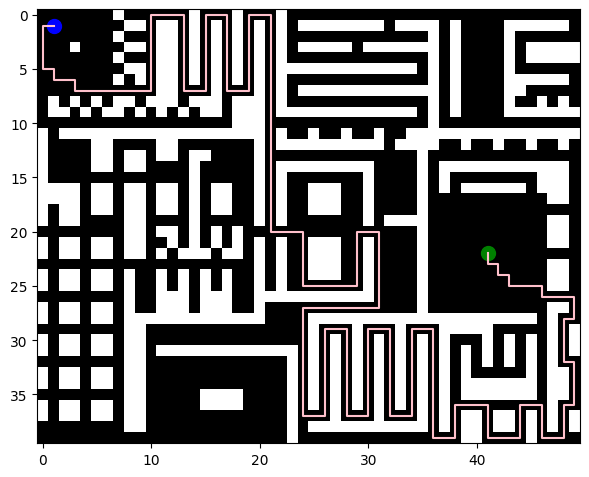

In [ ]:
# Please keep your parameters for the ACO easily changeable here
gen = 20
no_gen = 200
q = 1600
evap = 0.1
alpha = 3
beta = 2
memory_penalty = 0.01
memory_size = 20
greedy = 0.01

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt")
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, alpha, beta, memory_penalty, memory_size, greedy)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/medium_solution.txt")

v = Visualizer()
v.visualize_individual_path(maze, shortest_route, spec)

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [5]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, alpha, beta, memory_penalty, memory_size, greedy):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.alpha = alpha
        self.beta = beta
        self.memory_penalty = memory_penalty
        self.memory_size = memory_size
        self.greedy = greedy

    """
    Method that performs a single complete run through the maze by the ant
    Python lists were chosen here as they offer performance benefits over numpy arrays
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        eps = np.finfo(float).eps
        cur = self.start
        prev = cur

        # memory structures, set for performance
        mem = []
        mem_set = set()

        max_iters = self.maze.get_length() * self.maze.get_width() * 2
        iter = 0

        # precompute directions so that we don't have to every iteration
        directions = [
            Direction.east,
            Direction.north,
            Direction.west,
            Direction.south
        ]

        while cur != self.end and iter < max_iters:
            sp_arr = self.maze.get_surrounding_pheromone(cur)

            if sum(sp_arr) == 0.0:
                break

            positions = [cur.add_direction(d) for d in directions]

            des_arr = []
            for i in range(4):
                if sp_arr[i] == 0:
                    des_arr.append(0)
                elif positions[i] == prev:
                    des_arr.append(eps)
                elif positions[i] in mem_set:
                    des_arr.append(self.memory_penalty)
                else:
                    des_arr.append(1.0)

            # compute probabilities
            gp = -1
            g = None
            weights = []
            for i in range(4):
                w = (sp_arr[i] ** self.alpha) * (des_arr[i] ** self.beta)
                if w > gp:
                    gp = w
                    g = directions[i]
                weights.append(w)
            
            # add randomness to selection; ant decides to "do its own thing"

            total = sum(weights) + eps
            p = [w / total for w in weights]

            dp = random.choices(directions, p)[0]

            # some probability to just pick the direction with max pheromone instead of a probabilistic approach
            d = random.choices([dp, g], [1 - self.greedy, self.greedy])[0]

            route.add(d)

            prev = cur

            # update memory
            mem.append(cur)
            mem_set.add(cur)

            if len(mem) > self.memory_size:
                old = mem.pop(0)
                mem_set.discard(old)

            cur = cur.add_direction(d)
            iter += 1

        return route



When using the StandardAnt to explore the maze, we found that it quickly failed at exploring even the toy maze. The main problems are that before a complete run has been made, the ants move in random directions. This doesn't really change much, as there is no reward given to ants that make it further in the maze. So in other words, there is no meaningful way to denote that one path is better than another, and therefore should have greater amounts of pheramone deposited on its tiles.

As there is no way to rank paths that do not even reach the goal based on length (due to them all having the same length, "max_iters"), we will need to implement a more sophisticated method to calculate desirability (typically $\eta$ = $\dfrac{1}{\text{distance}}$ in a graph-based approach).

Two possible approaches that can be used are:

1. To give the ants memory, so that previously-visited cells are de-prioritised.

2. Parameterised noise to the probabilities; rather than purely relying on the pheromone and memory components, we allow the ants to sometimes just make their own decisions, and the frequency of this is something that we can adjust for; this allows us to balance exploration and reliance on what previous ants have done

To further expand on the idea of giving our ants a memory, there are a few different ways that this could be done: first, giving all memory cells an equal penalty, giving more recent ones a greater penalty, and giving less recent ones a greater penalty. We will try all three, compare and comment on the results, and select the best method. A current hypothesis is that giving less recent cells a greater penalty is better, as in the case of a loop, it would be worse for the ant to return to the breaking off point of the loop and for repeating the loop to be a more desirable path than turing around.

Additionally, we added $\alpha$ and $\beta$ hyperparameters to tune the weight of the pheromone and desirability signalling when calculating probabilities for where an ant should move next in its route.

### 2.5 Parameter Optimization

#### Question 16

In [ ]:
alphas = [1,2,3,4]
betas = [0.25, 0.5, 0.75, 1.5, 3]
evaps = [0.025, 0.05, 0.1, 0.15]
best_length = float("inf")
best_params = None
best_time = float("inf")
results = []

maze = Maze.create_maze("./../data/medium_maze.txt")
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

for alpha in alphas:
    for beta in betas:
        for evap in evaps:
            print("\nCase: ", alpha, beta, evap)
            total_length = 0
            total_time = 0
            runs = 1

            for i in range(runs):
                aco = AntColonyOptimization(maze, gen, no_gen, q, evap, alpha, beta, memory_penalty, memory_size, greedy)
                start_time = int(round(time.time() * 1000))
                shortest_route = aco.find_shortest_route(spec)
                total_time += (int(round(time.time() * 1000)) - start_time) / 1000.0
                total_length += shortest_route.size()

            length = total_length / runs
            timer = total_time / runs
            results.append({
                "alpha": alpha,
                "beta": beta,
                "evap": evap,
                "length": length,
                "time": timer
            })
            print("Length: ", length, "Time: ", timer)

            if length < best_length:
                best_length = length
                best_params = (alpha, beta, evap)
            elif length == best_length and timer < best_time:
                best_time = timer
                best_params = (alpha, beta, evap)

print("\nBest: ", best_length, best_time, best_params)

alphas_plot = [r["alpha"] for r in results]
betas_plot = [r["beta"] for r in results]
evaps_plot = [r["evap"] for r in results]
lengths = [r["length"] for r in results]
times = [r["time"] for r in results]

plt.figure()
plt.scatter(alphas_plot, lengths)
plt.xlabel("Alpha")
plt.ylabel("Path Length")
plt.title("Alpha vs Path Length")
plt.show()

plt.figure()
plt.scatter(betas_plot, lengths)
plt.xlabel("Beta")
plt.ylabel("Path Length")
plt.title("Beta vs Path Length")
plt.show()

plt.figure()
plt.scatter(evaps_plot, lengths)
plt.xlabel("Evaporation Rate")
plt.ylabel("Path Length")
plt.title("Evaporation vs Path Length")
plt.show()

Ready reading maze file ./../data/medium_maze.txt

Case:  1 0.25 0.025
Length:  195.0 Time:  59.403

Case:  1 0.25 0.05
Length:  195.0 Time:  34.922

Case:  1 0.25 0.1
Length:  195.0 Time:  19.27

Case:  1 0.5 0.025
Length:  195.0 Time:  11.596

Case:  1 0.5 0.05
Length:  195.0 Time:  11.949

Case:  1 0.5 0.1
Length:  195.0 Time:  11.808

Case:  1 0.75 0.025
Length:  195.0 Time:  11.853

Case:  1 0.75 0.05
Length:  195.0 Time:  11.781

Case:  1 0.75 0.1
Length:  195.0 Time:  11.838

Case:  1 1.5 0.025
Length:  195.0 Time:  12.083

Case:  1 1.5 0.05
Length:  195.0 Time:  11.691

Case:  1 1.5 0.1
Length:  195.0 Time:  11.746

Case:  1 3 0.025
Length:  195.0 Time:  11.741

Case:  1 3 0.05
Length:  195.0 Time:  11.989

Case:  1 3 0.1
Length:  195.0 Time:  11.919

Case:  2 0.25 0.025
Length:  195.0 Time:  11.76

Case:  2 0.25 0.05
Length:  195.0 Time:  11.517

Case:  2 0.25 0.1
Length:  195.0 Time:  11.325

Case:  2 0.5 0.025
Length:  195.0 Time:  11.165

Case:  2 0.5 0.05
Length:  195.0 Ti

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [0]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**